# Facial Emotion Detection System

## 1. Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# Check GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
try:
    # Disable scientific notation for clarity
    np.set_printoptions(suppress=True)
except:
    pass

Num GPUs Available:  0


## 2. Data Preprocessing

In [5]:
# 2. Load Data from Organized Folders
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

DATA_DIR = 'data/organized'
EMOTIONS = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
class_map = {emotion: idx for idx, emotion in enumerate(EMOTIONS)}

print('Loading images from directories...')
images = []
labels = []

for emotion in EMOTIONS:
    folder_path = os.path.join(DATA_DIR, emotion)
    if not os.path.exists(folder_path):
        print(f'Warning: Folder missing - {folder_path}')
        continue
        
    label = class_map[emotion]
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            images.append(img)
            labels.append(label)

images = np.array(images, dtype='float32') / 255.0
images_input = np.expand_dims(images, axis=-1)
labels = np.array(labels)

y_train_onehot_full = to_categorical(labels, num_classes=len(EMOTIONS))

# Split into train/test
X_train, X_test, y_train_onehot, y_test_onehot = train_test_split(
    images_input, y_train_onehot_full, test_size=0.2, random_state=42, stratify=labels
)

print(f'Total images loaded: {len(images)}')
print(f'Training set size: {X_train.shape[0]}')
print(f'Validation set size: {X_test.shape[0]}')
print(f'Input shape: {X_train.shape[1:]}')


Loading images from directories...
Total images loaded: 35340
Training set size: 28272
Validation set size: 7068
Input shape: (48, 48, 1)


## 3. Model Definition

In [6]:
def build_model(input_shape=(48, 48, 1), num_classes=6):
    model = Sequential()

    # 1st Convolution Block
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 2nd Convolution Block
    model.add(Conv2D(128, (5, 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 3rd Convolution Block
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 4th Convolution Block
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten and Dense
    model.add(Flatten())
    
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Output
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model()
model.summary()

c:\projects\Facial Emotion Detection System\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,478,214 (17.08 MB)

 Trainable params: 4,474,246 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

## 4. Model Training

In [7]:
# 4. Model Training with Augmentation and Class Weights
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

BATCH_SIZE = 64
EPOCHS = 120

# Compute Class Weights
y_train_ints = np.argmax(y_train_onehot, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_ints),
    y=y_train_ints
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Computed Class Weights: {class_weight_dict}')

# Define Callbacks
checkpoint = ModelCheckpoint('Models/emotion_model_nb.keras', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)
callbacks_list = [checkpoint, reduce_lr, early_stop]

# Setup Data Augmentation
print('\nSetting up ImageDataGenerator...')
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Train the model
print('\nStarting Model Training with Augmentation...')
history = model.fit(
    datagen.flow(X_train, y_train_onehot, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_onehot),
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weight_dict
)


Computed Class Weights: {0: np.float64(1.1892983341746592), 1: np.float64(1.1501098364657065), 2: np.float64(0.655263523849256), 3: np.float64(0.9503832190399355), 4: np.float64(0.9691484985602633), 5: np.float64(1.47158026233604)}

Setting up ImageDataGenerator...

Starting Model Training with Augmentation...
Epoch 1/120
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.1865 - loss: 2.7388
Epoch 1: val_accuracy improved from None to 0.21095, saving model to Models/emotion_model_nb.keras

Epoch 1: finished saving model to Models/emotion_model_nb.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 170s 377ms/step - accuracy: 0.1886 - loss: 2.6188 - val_accuracy: 0.2110 - val_loss: 2.0631 - learning_rate: 1.0000e-04
Epoch 2/120
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.1958 - loss: 2.3947
Epoch 2: val_accuracy improved from 0.21095 to 0.25552, saving model to Models/emotion_model_nb.keras

Epoch 2: finished saving model to Models/emotion_model_nb.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 1

## 5. Evaluation

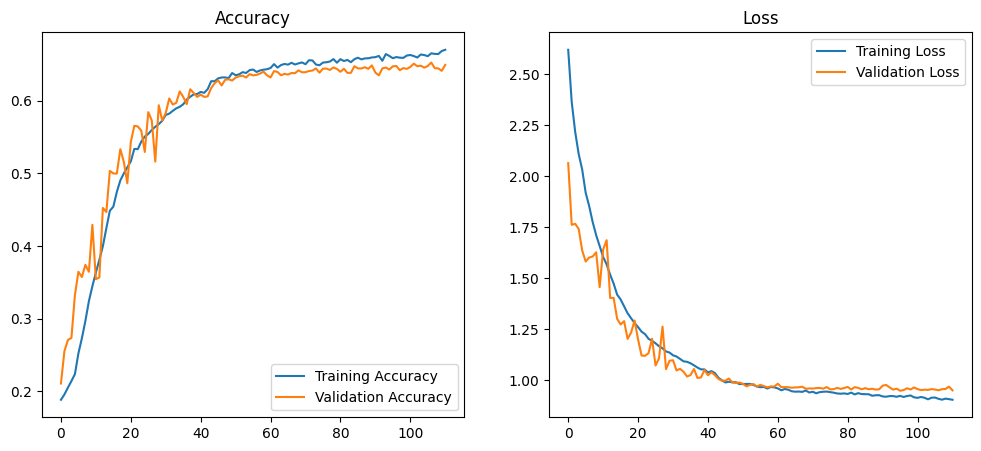

In [8]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

## 6. Real-Time Detection (Webcam)
Run the following cell to start the webcam. Press **'q'** to quit the window.

In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model (ensure this path matches where you saved it)
model = load_model('Models/emotion_model_final_v1.keras')

# Emotion Labels
EMOTION_LABELS = {0: 'Anger', 1: 'Fear', 2: 'Happy', 3: 'Sad', 4: 'Surprise', 5: 'Neutral'}

# Load Face Cascade
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face_cascade_path)

# Start Webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam")
else:
    print("Webcam started. Press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Mirror image
        frame = cv2.flip(frame, 1)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
        
        for (x, y, w, h) in faces:
            # Preprocess face
            roi_gray = gray[y:y+h, x:x+w]
            roi_gray = cv2.resize(roi_gray, (48, 48))
            roi_gray = roi_gray.astype('float32') / 255.0
            roi_gray = np.expand_dims(roi_gray, axis=0)
            roi_gray = np.expand_dims(roi_gray, axis=-1)
            
            # Predict
            prediction = model.predict(roi_gray, verbose=0)
            max_index = int(np.argmax(prediction))
            label = EMOTION_LABELS[max_index]
            confidence = prediction[0][max_index]
            
            # Draw
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, f"{label} ({confidence:.2f})", (x, y-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        
        cv2.imshow('Facial Emotion Detection', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

Webcam started. Press 'q' to quit.
